# Enriquecimento de Dataset Imobiliário — VivaReal (RMF)

Pipeline para limpeza, correção e enriquecimento de anúncios imobiliários extraídos via scraping do VivaReal,
preparando os dados para treinamento de modelos de previsão de preço.

**Princípio geral:** as colunas estruturadas podem estar incorretas ou incompletas. Sempre que houver conflito entre
texto (`descricao`, `titulo`, `endereco`) e colunas estruturadas, a prioridade de resolução é:

1. `descricao`
2. `titulo`
3. colunas estruturadas (fallback)

## Etapas do pipeline
1. Carga dos dados e preparação de texto consolidado
2. Normalização de `cidade` (validação contra municípios da RMF)
3. Normalização de `bairro` (grafias divergentes → forma canônica)
4. Normalização de `rua`
5. Extração numérica: metragem, quartos, banheiros, suítes, andar, vagas
6. Extração de amenidades (17 atributos booleanos)
7. Detecção de características especiais (nascente, andar alto, mobiliado, etc.)
8. Detecção do tipo de anúncio (normal / lançamento / repasse / leilão)
9. Detecção de termos de financiamento
10. Detecção de múltiplas unidades (anúncios com faixa de metragem/preço)
11. Geração de `observacoes_extraidas` com achados sem coluna própria
12. Consolidação do dataset final e exportação


In [104]:
import re
import os
import unicodedata
import pandas as pd
import numpy as np
from pathlib import Path


pd.set_option("display.max_columns", 60)


## 1. Carga dos dados

Leitura do CSV bruto e criação de um campo de texto consolidado (`_texto_full`) combinando
`descricao`, `titulo` e `endereco`, que será usado por todos os extratores baseados em regex.

In [105]:
def encontrar_raiz_repositorio(inicio=None):
    """Localiza a raiz do repositório a partir do diretório atual."""
    inicio = Path(inicio or os.getcwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        csv_esperado = candidato / "scraping" / "outputs" / "vivareal_live_10k.csv"
        if csv_esperado.exists():
            return candidato
    raise FileNotFoundError("Não encontrei scraping/outputs/vivareal_live_10k.csv a partir do diretório atual.")

REPO_ROOT = encontrar_raiz_repositorio()
INPUT_PATH = REPO_ROOT / "scraping" / "outputs" / "vivareal_live_10k.csv"

print("Raiz do repositório:", REPO_ROOT)
print("CSV carregado:", INPUT_PATH)

df = pd.read_csv(INPUT_PATH)
print("Shape original:", df.shape)
df.head(2)


Raiz do repositório: C:\Users\andriel_orbi\Tiago\git\pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real
CSV carregado: C:\Users\andriel_orbi\Tiago\git\pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real\scraping\outputs\vivareal_live_10k.csv
Shape original: (1032, 36)


,listing_id,titulo,apartamento_ou_casa,tipo_imovel,estado,cidade,bairro,rua,numero,endereco,metragem,quartos,banheiros,suites,andar,estacionamentos,preco_anuncio,latitude,longitude,tem_portaria_24h,tem_vista_pro_mar,tem_condominio_fechado,tem_piscina,tem_deck,tem_varanda_gourmet,tem_varanda,tem_academia,tem_salao_festas,tem_salao_jogos,tem_quadra_campo,descricao,anuncio_criado,corretora,nota_media,url,imagem_url
0,2867922980,"Apartamento para comprar com 37 - 51 m², 1 qua...",Apartamento,Apartamento,CE,Fortaleza,Aldeota,Rua José Vilar,1264,"Rua José Vilar 1264, Aldeota, Fortaleza, CE",37,1.0,2.0,1.0,0,1.0,549.000,-3.735524,-38.504891,False,False,False,False,False,False,False,True,False,False,False,O J.Smart José Vilar é um empreendimento inova...,NaN,Bom Negocio Atividades De Internet Ltda,0.0,https://www.vivareal.com.br/imoveis-lancamento...,https://resizedimgs.vivareal.com/img/vr-listin...
1,2892042890,"Apartamento para comprar com 80 m², 3 quartos,...",Apartamento,Apartamento,CE,Fortaleza,Jacarecanga,Avenida Francisco Sá,2101,"Avenida Francisco Sá 2101, Jacarecanga, Fortal...",80,3.0,2.0,2.0,10,2.0,429.000,-3.721913,-38.544388,True,False,True,True,True,False,False,True,True,True,False,"Apartamento com 3 quartos sendo 2 suites,com 8...",2026-06-10,Daniel Pinheiro Cardoso,0.0,https://www.vivareal.com.br/imovel/apartamento...,https://resizedimgs.vivareal.com/img/vr-listin...


In [106]:
df["_titulo_n"] = df["titulo"].fillna("")
df["_descricao_n"] = df["descricao"].fillna("")
df["_endereco_n"] = df["endereco"].fillna("")
df["_texto_full"] = (
    df["_descricao_n"] + " || " + df["_titulo_n"] + " || " + df["_endereco_n"]
)

def strip_accents(s):
    if not isinstance(s, str):
        return s
    return "".join(
        c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn"
    )

def norm_lower(s):
    return strip_accents(str(s)).lower()


## 2. Normalização de `cidade`

Valida e corrige a cidade com base na lista oficial de municípios da Região Metropolitana de Fortaleza (RMF).
Busca o nome do município no texto (descrição → título → endereço, nessa ordem) antes de cair no valor estrutural.

In [107]:
MUNICIPIOS_RMF = [
    "Aquiraz", "Cascavel", "Caucaia", "Chorozinho", "Eusébio", "Fortaleza",
    "Guaiúba", "Horizonte", "Itaitinga", "Maracanaú", "Maranguape", "Pacajus",
    "Pacatuba", "Paracuru", "Paraipaba", "Pindoretama", "São Gonçalo do Amarante",
    "São Luís do Curu", "Trairi",
]
MUNICIPIOS_NORM = {norm_lower(m): m for m in MUNICIPIOS_RMF}
MUNICIPIOS_NORM["sao goncalo do amarante"] = "São Gonçalo do Amarante"
MUNICIPIOS_NORM["sgda"] = "São Gonçalo do Amarante"
MUNICIPIOS_NORM["sao luis do curu"] = "São Luís do Curu"

def detectar_cidade(row):
    """Detecta cidade priorizando descrição > título > coluna estruturada."""
    texto_desc = norm_lower(row["_descricao_n"])
    texto_tit = norm_lower(row["_titulo_n"])
    texto_end = norm_lower(row["_endereco_n"])
    cidade_estrutural = row.get("cidade")

    for texto in (texto_desc, texto_tit, texto_end):
        for chave, nome_oficial in MUNICIPIOS_NORM.items():
            if re.search(r"\b" + re.escape(chave) + r"\b", texto):
                return nome_oficial

    if isinstance(cidade_estrutural, str):
        chave = norm_lower(cidade_estrutural)
        if chave in MUNICIPIOS_NORM:
            return MUNICIPIOS_NORM[chave]

    return cidade_estrutural if isinstance(cidade_estrutural, str) else np.nan

df["cidade_normalizada"] = df.apply(detectar_cidade, axis=1)
df["cidade_normalizada"].value_counts(dropna=False)


cidade_normalizada
Fortaleza    998
Eusébio       22
Aquiraz       10
Caucaia        1
Maracanaú      1
Name: count, dtype: int64

## 3. Normalização de `bairro`

Padroniza grafias diferentes do mesmo bairro para uma forma canônica (ex.: `Sapiranga / Coité`,
`Lagoa Sapiranga Coité` → `Sapiranga-Coité`). Quando a coluna estruturada está vazia, tenta extrair o bairro
a partir do campo `endereco` (padrão `Rua X, Bairro, Cidade, UF`).

In [108]:
BAIRRO_CANONICO = {
    "sapiranga / coite": "Sapiranga-Coité",
    "sapiranga-coite": "Sapiranga-Coité",
    "lagoa sapiranga coite": "Sapiranga-Coité",
    "sapiranga coite": "Sapiranga-Coité",
    "dionisio torres": "Dionísio Torres",
    "manoel dias branco": "Manuel Dias Branco",
    "manuel dias branco": "Manuel Dias Branco",
    "manoel satiro": "Manuel Sátiro",
    "manuel satiro": "Manuel Sátiro",
    "jose de alencar": "José de Alencar",
    "agua fria": "Água Fria",
    "boa vista-castelao": "Boa Vista/Castelão",
    "boa vista castelao": "Boa Vista/Castelão",
}

def normalizar_bairro(valor):
    if not isinstance(valor, str) or not valor.strip():
        return np.nan
    chave = norm_lower(valor).strip()
    chave = re.sub(r"\s+", " ", chave)
    if chave in BAIRRO_CANONICO:
        return BAIRRO_CANONICO[chave]
    return valor.strip()

df["bairro_normalizado"] = df["bairro"].apply(normalizar_bairro)

def extrair_bairro_do_texto(row):
    if isinstance(row["bairro_normalizado"], str) and row["bairro_normalizado"]:
        return row["bairro_normalizado"]
    end = row["_endereco_n"]
    partes = [p.strip() for p in end.split(",")]
    if len(partes) >= 3:
        candidato = partes[-3]
        if candidato:
            return normalizar_bairro(candidato)
    return row["bairro_normalizado"]

df["bairro_normalizado"] = df.apply(extrair_bairro_do_texto, axis=1)
df["bairro_normalizado"].value_counts(dropna=False).head(10)


bairro_normalizado
Engenheiro Luciano Cavalcante    95
Aldeota                          74
Cocó                             65
Edson Queiroz                    53
Mondubim                         43
Meireles                         43
NaN                              41
Papicu                           34
Praia do Futuro II               32
Parque Dois Irmãos               29
Name: count, dtype: int64

## 4. Normalização de `rua`

Usa a coluna estruturada quando disponível; senão extrai do `endereco`.

In [109]:
def normalizar_rua(row):
    if isinstance(row.get("rua"), str) and row["rua"].strip():
        return row["rua"].strip()
    end = row["_endereco_n"]
    partes = [p.strip() for p in end.split(",")]
    if partes and partes[0]:
        return re.sub(r"\s+\d+$", "", partes[0]).strip()
    return np.nan

df["rua_normalizada"] = df.apply(normalizar_rua, axis=1)
df["rua_normalizada"].head(5)


0          Rua José Vilar
1    Avenida Francisco Sá
2      Rua Jaime Benévolo
3       Estrada do Jatobá
4                   Rua J
Name: rua_normalizada, dtype: object

## 5. Extração numérica: metragem, quartos, banheiros, suítes, andar, vagas

Para cada atributo, busca primeiro o padrão na `descricao`, depois no `titulo`, e só então usa a coluna
estruturada como fallback. Para imóveis com faixa de metragem (ex. `37 - 51 m²`), utiliza o menor valor da
faixa como referência (o registro também será marcado como `multipla_unidade`, ver seção 10).

In [110]:
def buscar_padrao(texto, padroes):
    for p in padroes:
        m = re.search(p, texto, flags=re.IGNORECASE)
        if m:
            return m.group(1)
    return None

def extrair_metragem(row):
    desc = row["_descricao_n"]
    tit = row["_titulo_n"]
    padroes_simples = [
        r"(\d{2,4}(?:[.,]\d{1,2})?)\s*m\u00b2\s*de\s*(?:\u00e1rea|area)",
        r"(\d{2,4}(?:[.,]\d{1,2})?)\s*m\u00b2",
        r"(\d{2,4}(?:[.,]\d{1,2})?)\s*m2\b",
    ]
    for texto in (desc, tit):
        m = re.search(r"(\d{2,4})\s*(?:m\u00b2|m2)?\s*(?:a|[-\u2013])\s*(\d{2,4})\s*m\u00b2", texto, flags=re.IGNORECASE)
        if m:
            return float(m.group(1))
        valor = buscar_padrao(texto, padroes_simples)
        if valor:
            return float(valor.replace(",", "."))
    if pd.notna(row.get("metragem")):
        return float(row["metragem"])
    return np.nan

def extrair_quartos(row):
    for texto in (row["_descricao_n"], row["_titulo_n"]):
        m = re.search(r"(\d+)\s*(?:quartos?|dormit\u00f3rios?)", texto, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    if pd.notna(row.get("quartos")):
        return int(row["quartos"])
    return np.nan

def extrair_banheiros(row):
    for texto in (row["_descricao_n"], row["_titulo_n"]):
        m = re.search(r"(\d+)\s*banheiros?", texto, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    if pd.notna(row.get("banheiros")):
        return int(row["banheiros"])
    return np.nan

def extrair_suites(row):
    for texto in (row["_descricao_n"], row["_titulo_n"]):
        m = re.search(r"(\d+)\s*su\u00edtes?", texto, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
        m2 = re.search(r"sendo\s*(\d+)\s*su\u00edtes?", texto, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))
    if pd.notna(row.get("suites")):
        return int(row["suites"])
    return np.nan

def extrair_andar(row):
    for texto in (row["_descricao_n"], row["_titulo_n"]):
        m = re.search(r"(\d+)\s*[\u00ba\u00b0o]?\s*andar", texto, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    if pd.notna(row.get("andar")):
        try:
            return int(row["andar"])
        except (ValueError, TypeError):
            return np.nan
    return np.nan

def extrair_vagas(row):
    for texto in (row["_descricao_n"], row["_titulo_n"]):
        m = re.search(r"(\d+)\s*vagas?", texto, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    if pd.notna(row.get("estacionamentos")):
        return int(row["estacionamentos"])
    return np.nan

df["metragem_normalizada"] = df.apply(extrair_metragem, axis=1)
df["quartos_normalizado"] = df.apply(extrair_quartos, axis=1)
df["banheiros_normalizado"] = df.apply(extrair_banheiros, axis=1)
df["suites_normalizado"] = df.apply(extrair_suites, axis=1)
df["andar_normalizado"] = df.apply(extrair_andar, axis=1)
df["vagas_normalizado"] = df.apply(extrair_vagas, axis=1)

df[["metragem_normalizada", "quartos_normalizado", "banheiros_normalizado",
    "suites_normalizado", "andar_normalizado", "vagas_normalizado"]].describe()


,metragem_normalizada,quartos_normalizado,banheiros_normalizado,suites_normalizado,andar_normalizado,vagas_normalizado
count,1032.000000,905.000000,933.000000,875.000000,1032.000000,942.000000
mean,140.168614,2.750276,2.652733,2.082286,4.847868,2.117834
std,151.008542,0.987512,1.477109,6.937781,63.897842,3.988549
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,52.000000,2.000000,1.000000,1.000000,0.000000,1.000000
50%,93.875000,3.000000,2.000000,2.000000,0.000000,2.000000
75%,161.000000,3.000000,4.000000,3.000000,2.000000,2.000000
max,1506.000000,17.000000,12.000000,203.000000,2024.000000,112.000000


## 6. Extração de amenidades

Cada amenidade é detectada por palavras-chave (regex) no texto consolidado. Quando existe coluna booleana
estruturada equivalente (`tem_*`), o resultado final é a união lógica (`OR`) entre o que foi detectado no
texto e o valor estrutural — isso corrige falsos negativos da coluna original sem descartar verdadeiros
positivos que só estavam na estrutura.

In [111]:
AMENIDADES_KEYWORDS = {
    "portaria_24h_normalizado": [r"portaria\s*24\s*h", r"seguranc[ay]\s*24\s*horas", r"portaria\s*via\s*app"],
    "vista_mar_normalizado": [r"vista\s*(para\s*o\s*|pro\s*|do\s*)?mar"],
    "condominio_fechado_normalizado": [r"condom\u00ednio\s*fechado"],
    "piscina_normalizado": [r"piscina"],
    "deck_normalizado": [r"\bdeck\b"],
    "varanda_normalizado": [r"\bvaranda\b(?!\s*gourmet)"],
    "varanda_gourmet_normalizado": [r"varanda\s*gourmet", r"terra[c\u00e7]o\s*gourmet"],
    "academia_normalizado": [r"academia"],
    "salao_festas_normalizado": [r"sal[a\u00e3]o\s*de\s*festas?"],
    "salao_jogos_normalizado": [r"sal[a\u00e3]o\s*de\s*jogos?"],
    "quadra_normalizado": [r"quadra\s*(de\s*)?(esportes?|campo|poliesportiva|tenis)?"],
    "playground_normalizado": [r"playground", r"parquinho"],
    "brinquedoteca_normalizado": [r"brinquedoteca"],
    "coworking_normalizado": [r"co[\s-]?working"],
    "pet_place_normalizado": [r"pet\s*place", r"pet\s*care", r"espaco\s*pet"],
    "elevador_normalizado": [r"elevador"],
    "energia_solar_normalizado": [r"energia\s*solar", r"placas?\s*solares?"],
}

COLUNA_BOOL_MAP = {
    "portaria_24h_normalizado": "tem_portaria_24h",
    "vista_mar_normalizado": "tem_vista_pro_mar",
    "condominio_fechado_normalizado": "tem_condominio_fechado",
    "piscina_normalizado": "tem_piscina",
    "deck_normalizado": "tem_deck",
    "varanda_gourmet_normalizado": "tem_varanda_gourmet",
    "varanda_normalizado": "tem_varanda",
    "academia_normalizado": "tem_academia",
    "salao_festas_normalizado": "tem_salao_festas",
    "salao_jogos_normalizado": "tem_salao_jogos",
    "quadra_normalizado": "tem_quadra_campo",
}

def detectar_amenidade(texto_norm, padroes):
    return any(re.search(p, texto_norm, flags=re.IGNORECASE) for p in padroes)

textos_norm = df["_texto_full"].apply(norm_lower)

for amenidade, padroes in AMENIDADES_KEYWORDS.items():
    encontrado_texto = textos_norm.apply(lambda t: detectar_amenidade(t, padroes))
    coluna_bool = COLUNA_BOOL_MAP.get(amenidade)
    if coluna_bool and coluna_bool in df.columns:
        estrutural = df[coluna_bool].fillna(False).astype(bool)
        df[amenidade] = encontrado_texto | estrutural
    else:
        df[amenidade] = encontrado_texto

df[list(AMENIDADES_KEYWORDS.keys())].sum().sort_values(ascending=False)


piscina_normalizado               609
deck_normalizado                  577
salao_festas_normalizado          572
academia_normalizado              471
varanda_normalizado               441
playground_normalizado            383
quadra_normalizado                376
condominio_fechado_normalizado    340
portaria_24h_normalizado          339
varanda_gourmet_normalizado       194
elevador_normalizado              171
brinquedoteca_normalizado         168
salao_jogos_normalizado           140
pet_place_normalizado             132
coworking_normalizado              80
vista_mar_normalizado              48
energia_solar_normalizado          19
dtype: int64

## 7. Características especiais

Atributos binários adicionais que descrevem qualidades do imóvel não cobertas pelas amenidades de condomínio.

In [112]:
CARACTERISTICAS_KEYWORDS = {
    "nascente_normalizado": [r"\bnascente\b"],
    "andar_alto_normalizado": [r"andar\s*alto"],
    "mobiliado_normalizado": [r"mobiliad[ao]", r"semi[\s-]?mobiliad[ao]"],
    "reformado_normalizado": [r"reformad[ao]"],
    "frente_mar_normalizado": [r"frente\s*(ao\s*|pro\s*|para\s*o\s*)?mar", r"beira\s*mar"],
    "vista_livre_normalizado": [r"vista\s*livre"],
}

for carac, padroes in CARACTERISTICAS_KEYWORDS.items():
    df[carac] = textos_norm.apply(lambda t: detectar_amenidade(t, padroes))

df[list(CARACTERISTICAS_KEYWORDS.keys())].sum()


nascente_normalizado       137
andar_alto_normalizado      53
mobiliado_normalizado       61
reformado_normalizado       29
frente_mar_normalizado      28
vista_livre_normalizado     19
dtype: int64

## 8. Tipo de anúncio

Classifica cada registro em `normal`, `lançamento`, `repasse` ou `leilão`, com prioridade
`leilão` > `repasse` > `lançamento` > `normal` (também considera a URL, que costuma indicar lançamentos
através do path `imoveis-lancamentos`).

In [113]:
def detectar_tipo_anuncio(texto_norm, url):
    if re.search(r"leil[a\u00e3]o", texto_norm):
        return "leil\u00e3o"
    if re.search(r"\brepasse\b", texto_norm):
        return "repasse"
    if re.search(r"lan[c\u00e7]amento", texto_norm) or "imoveis-lancamentos" in str(url).lower():
        return "lan\u00e7amento"
    return "normal"

df["tipo_anuncio_normalizado"] = [
    detectar_tipo_anuncio(t, u) for t, u in zip(textos_norm, df["url"])
]
df["tipo_anuncio_normalizado"].value_counts()


tipo_anuncio_normalizado
normal        878
lançamento     66
repasse        64
leilão         24
Name: count, dtype: int64

## 9. Financiamento

Detecta menções a saldo devedor, parcelas restantes e condições de entrada.

In [114]:
FINANCIAMENTO_KEYWORDS = {
    "saldo_devedor_normalizado": [r"saldo\s*devedor"],
    "parcelas_restantes_normalizado": [r"parcelas?\s*restantes?", r"parcelas?\s*a\s*pagar"],
    "entrada_normalizado": [r"\bentrada\s*de\b", r"\bentrada\s*\+", r"entrada\s*facilitada", r"entrada\s*r\$"],
}

for chave, padroes in FINANCIAMENTO_KEYWORDS.items():
    df[chave] = textos_norm.apply(lambda t: detectar_amenidade(t, padroes))

df[list(FINANCIAMENTO_KEYWORDS.keys())].sum()


saldo_devedor_normalizado         46
parcelas_restantes_normalizado     0
entrada_normalizado               26
dtype: int64

## 10. Múltiplas unidades

Identifica anúncios que representam mais de uma unidade (faixas de metragem, "unidades a partir de", etc.),
um padrão comum em lançamentos.

In [115]:
MULTIPLA_UNIDADE_PADROES = [
    r"\d{2,4}\s*(?:m\u00b2|m2)?\s*(?:a|[-\u2013])\s*\d{2,4}\s*m\u00b2",
    r"unidades?\s*a\s*partir\s*de",
    r"apartamentos?\s*a\s*partir\s*de",
    r"a\s*partir\s*de\s*r?\$?\s*\d",
]

df["multipla_unidade_normalizado"] = textos_norm.apply(
    lambda t: detectar_amenidade(t, MULTIPLA_UNIDADE_PADROES)
)
df["multipla_unidade_normalizado"].value_counts()


multipla_unidade_normalizado
False    955
True      77
Name: count, dtype: int64

## 11. Observações extraídas

Captura, em uma única coluna textual, sinais relevantes do anúncio que não possuem coluna estruturada
própria (ex.: churrasqueira, duplex, cobertura, proximidade a shopping/praia/escola, permuta, etc.).

In [116]:
OBSERVACOES_KEYWORDS = {
    "lavanderia_compartilhada": [r"lavanderia\s*compartilhada"],
    "loja_conveniencia": [r"loja\s*de\s*conveni\u00eancia"],
    "sky_lounge": [r"sky\s*lounge"],
    "fechadura_eletronica": [r"fechaduras?\s*eletr\u00f4nicas?"],
    "espaco_gourmet": [r"espa[c\u00e7]o\s*gourmet"],
    "churrasqueira": [r"churrasqueira"],
    "perto_shopping": [r"shopping"],
    "perto_praia": [r"\bpraia\b"],
    "perto_escola": [r"col\u00e9gio|escola"],
    "pronto_para_morar": [r"pronto\s*(a|para)\s*morar", r"entregue\s*em"],
    "esquina": [r"\besquina\b"],
    "duplex": [r"\bduplex\b"],
    "cobertura": [r"\bcobertura\b"],
    "permuta": [r"\bpermuta\b"],
    "financiamento_bancario": [r"financiamento\s*banc\u00e1rio", r"aceita\s*financiamento"],
}

def gerar_observacoes(texto_norm):
    achados = [nome for nome, padroes in OBSERVACOES_KEYWORDS.items() if detectar_amenidade(texto_norm, padroes)]
    return "; ".join(achados) if achados else ""

df["observacoes_extraidas_normalizado"] = textos_norm.apply(gerar_observacoes)
df["observacoes_extraidas_normalizado"].head(5)


0    lavanderia_compartilhada; sky_lounge; pronto_p...
1                                       perto_shopping
2                                         perto_escola
3                                                     
4                                                     
Name: observacoes_extraidas_normalizado, dtype: object

## 12. Consolidação do dataset final

Seleciona e renomeia as colunas finais (estruturadas normalizadas + atributos derivados), removendo as
colunas auxiliares de texto, e exporta o resultado em CSV pronto para uso em modelagem.

In [117]:
colunas_finais = [
    "listing_id", "titulo", "tipo_imovel", "estado",
    "cidade_normalizada", "bairro_normalizado", "rua_normalizada", "numero",
    "metragem_normalizada", "quartos_normalizado", "banheiros_normalizado",
    "suites_normalizado", "andar_normalizado", "vagas_normalizado",
    "preco_anuncio", "latitude", "longitude",
    "portaria_24h_normalizado", "vista_mar_normalizado", "condominio_fechado_normalizado", "piscina_normalizado", "deck_normalizado",
    "varanda_normalizado", "varanda_gourmet_normalizado", "academia_normalizado", "salao_festas_normalizado", "salao_jogos_normalizado",
    "quadra_normalizado", "playground_normalizado", "brinquedoteca_normalizado", "coworking_normalizado", "pet_place_normalizado",
    "elevador_normalizado", "energia_solar_normalizado",
    "nascente_normalizado", "andar_alto_normalizado", "mobiliado_normalizado", "reformado_normalizado", "frente_mar_normalizado", "vista_livre_normalizado",
    "tipo_anuncio_normalizado",
    "saldo_devedor_normalizado", "parcelas_restantes_normalizado", "entrada_normalizado",
    "multipla_unidade_normalizado",
    "observacoes_extraidas_normalizado",
    "anuncio_criado", "corretora", "nota_media", "url",
]

remover_df_final = {
    "bairro_normalizado", "cidade_normalizada", "listing_id", "titulo", "estado",
    "rua_normalizada", "numero", "endereco", "tem_varanda_gourmet", "descricao",
    "corretora", "url", "imagem_url", "_titulo_n", "_descricao_n", "_endereco_n",
    "_texto_full", "andar_normalizado", "vagas_normalizado",
    "saldo_devedor_normalizado", "parcelas_restantes_normalizado", "entrada_normalizado",
    "observacoes_extraidas_normalizado", "multipla_unidade_normalizado",
    "energia_solar_normalizado",
}

colunas_finais = [col for col in colunas_finais if col not in remover_df_final]

df_final = df[colunas_finais].rename(columns={
    "metragem_normalizada": "metragem",
    "quartos_normalizado": "quartos",
    "banheiros_normalizado": "banheiros",
    "suites_normalizado": "suites",
})

print("Shape final:", df_final.shape)
df_final.head(5)


Shape final: (1032, 33)


,tipo_imovel,metragem,quartos,banheiros,suites,preco_anuncio,latitude,longitude,portaria_24h_normalizado,vista_mar_normalizado,condominio_fechado_normalizado,piscina_normalizado,deck_normalizado,varanda_normalizado,varanda_gourmet_normalizado,academia_normalizado,salao_festas_normalizado,salao_jogos_normalizado,quadra_normalizado,playground_normalizado,brinquedoteca_normalizado,coworking_normalizado,pet_place_normalizado,elevador_normalizado,nascente_normalizado,andar_alto_normalizado,mobiliado_normalizado,reformado_normalizado,frente_mar_normalizado,vista_livre_normalizado,tipo_anuncio_normalizado,anuncio_criado,nota_media
0,Apartamento,37.0,1.0,2.0,1.0,549.000,-3.735524,-38.504891,True,False,False,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,lançamento,NaN,0.0
1,Apartamento,80.0,3.0,2.0,2.0,429.000,-3.721913,-38.544388,True,True,True,True,True,False,True,True,True,True,False,False,False,False,False,False,True,True,False,False,False,False,normal,2026-06-10,0.0
2,Casa,345.0,4.0,4.0,3.0,649.000,-3.738268,-38.527359,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,normal,2025-12-13,0.0
3,Casa,180.0,2.0,2.0,1.0,70.000,-3.799722,-38.627113,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,repasse,2026-06-10,0.0
4,Casa,130.0,3.0,4.0,3.0,550.000,-3.835697,-38.548300,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,normal,2026-06-09,0.0


In [118]:
arquivo_original = Path(INPUT_PATH)

nome_saida = f"{arquivo_original.stem}_tratado.csv"

OUTPUT_DIR = REPO_ROOT / "dados_tratados"
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / nome_saida

df_final.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset salvo em: {OUTPUT_PATH}")


Dataset salvo em: C:\Users\andriel_orbi\Tiago\git\pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real\dados_tratados\vivareal_live_10k_tratado.csv


## 13. Checagem rápida de qualidade

Resumo de nulos e contagens por categoria, útil para validar a cobertura do enriquecimento antes de seguir
para a modelagem.

In [119]:
print("Nulos por coluna-chave:")
colunas_nulos = ["metragem", "quartos", "banheiros"]
colunas_nulos = [col for col in colunas_nulos if col in df_final.columns]
print(df_final[colunas_nulos].isna().sum())
print()
print("Tipo de an?ncio:")
print(df_final["tipo_anuncio_normalizado"].value_counts())


Nulos por coluna-chave:
metragem       0
quartos      127
banheiros     99
dtype: int64

Tipo de an?ncio:
tipo_anuncio_normalizado
normal        878
lançamento     66
repasse        64
leilão         24
Name: count, dtype: int64


In [120]:
display(df_final)

,tipo_imovel,metragem,quartos,banheiros,suites,preco_anuncio,latitude,longitude,portaria_24h_normalizado,vista_mar_normalizado,condominio_fechado_normalizado,piscina_normalizado,deck_normalizado,varanda_normalizado,varanda_gourmet_normalizado,academia_normalizado,salao_festas_normalizado,salao_jogos_normalizado,quadra_normalizado,playground_normalizado,brinquedoteca_normalizado,coworking_normalizado,pet_place_normalizado,elevador_normalizado,nascente_normalizado,andar_alto_normalizado,mobiliado_normalizado,reformado_normalizado,frente_mar_normalizado,vista_livre_normalizado,tipo_anuncio_normalizado,anuncio_criado,nota_media
0,Apartamento,37.00,1.0,2.0,1.0,549.000,-3.735524,-38.504891,True,False,False,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,lançamento,NaN,0.0
1,Apartamento,80.00,3.0,2.0,2.0,429.000,-3.721913,-38.544388,True,True,True,True,True,False,True,True,True,True,False,False,False,False,False,False,True,True,False,False,False,False,normal,2026-06-10,0.0
2,Casa,345.00,4.0,4.0,3.0,649.000,-3.738268,-38.527359,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,normal,2025-12-13,0.0
3,Casa,180.00,2.0,2.0,1.0,70.000,-3.799722,-38.627113,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,repasse,2026-06-10,0.0
4,Casa,130.00,3.0,4.0,3.0,550.000,-3.835697,-38.548300,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,normal,2026-06-09,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027,Apartamento,77.28,3.0,2.0,2.0,936.120,-3.739215,-38.510681,False,False,False,True,False,False,False,True,True,False,False,True,True,True,False,False,True,False,False,False,False,False,repasse,2026-04-15,0.0
1028,Lote/Terreno,614.59,NaN,NaN,NaN,4.800.000,-3.808000,-38.467000,False,False,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,normal,2024-05-08,0.0
1029,Apartamento,110.80,3.0,4.0,3.0,1.402.000,-3.727573,-38.488940,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,normal,2023-12-11,0.0
1030,Apartamento,178.00,3.0,5.0,3.0,750.000,-3.737000,-38.502000,True,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,normal,2023-12-20,0.0


In [121]:
print(df.shape)
print(df_final.shape)

(1032, 78)
(1032, 33)


## 14. Análise exploratória complementar

Complementa a checagem rápida com métricas voltadas à modelagem: cobertura dos campos, duplicidade, distribuição de preço/metragem, preço por m², outliers, rankings por localização e relação entre atributos numéricos.


In [122]:
df_eda = df_final.copy()

for col in ["preco_anuncio", "metragem", "quartos", "banheiros", "suites", "andar", "vagas", "latitude", "longitude", "nota_media"]:
    if col in df_eda.columns:
        df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

if "preco_m2" not in df_eda.columns:
    df_eda["preco_m2"] = np.where(
        (df_eda["metragem"].notna()) & (df_eda["metragem"] > 0),
        df_eda["preco_anuncio"] / df_eda["metragem"],
        np.nan,
    )

resumo_geral = pd.DataFrame({
    "metrica": [
        "linhas", "colunas", "listings_unicos", "urls_unicas",
        "preco_mediano", "metragem_mediana", "preco_m2_mediano",
        "bairros_unicos", "cidades_unicas",
    ],
    "valor": [
        len(df_eda), df_eda.shape[1],
        df_eda["listing_id"].nunique(dropna=True) if "listing_id" in df_eda else np.nan,
        df_eda["url"].nunique(dropna=True) if "url" in df_eda else np.nan,
        df_eda["preco_anuncio"].median(),
        df_eda["metragem"].median(),
        df_eda["preco_m2"].median(),
        df_eda["bairro"].nunique(dropna=True) if "bairro" in df_eda else np.nan,
        df_eda["cidade"].nunique(dropna=True) if "cidade" in df_eda else np.nan,
    ],
})

display(resumo_geral)

colunas_chave = [
    "preco_anuncio", "metragem", "preco_m2", "quartos", "banheiros", "vagas",
    "latitude", "longitude", "tipo_imovel", "tipo_anuncio_normalizado",
]
colunas_chave = [c for c in colunas_chave if c in df_eda.columns]

cobertura = (
    df_eda[colunas_chave]
    .notna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=True)
    .rename("cobertura_%")
    .reset_index()
    .rename(columns={"index": "coluna"})
)

display(cobertura)


,metrica,valor
0,linhas,1032.000000
1,colunas,34.000000
2,listings_unicos,NaN
3,urls_unicas,NaN
4,preco_mediano,466.500000
5,metragem_mediana,93.875000
6,preco_m2_mediano,5.217391
7,bairros_unicos,NaN
8,cidades_unicas,NaN


,coluna,cobertura_%
0,preco_m2,76.07
1,preco_anuncio,76.36
2,quartos,87.69
3,banheiros,90.41
4,longitude,96.03
5,latitude,96.03
6,metragem,100.00
7,tipo_imovel,100.00
8,tipo_anuncio_normalizado,100.00


In [123]:
numericas_modelo = ["preco_anuncio", "metragem", "preco_m2", "quartos", "banheiros", "suites", "andar", "vagas"]
numericas_modelo = [c for c in numericas_modelo if c in df_eda.columns]

display(df_eda[numericas_modelo].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

regras_outlier = {
    "preco_zerado_ou_vazio": df_eda["preco_anuncio"].isna() | (df_eda["preco_anuncio"] <= 0),
    "preco_muito_baixo": df_eda["preco_anuncio"] < 50_000,
    "preco_muito_alto": df_eda["preco_anuncio"] > 5_000_000,
    "metragem_muito_baixa": df_eda["metragem"] < 15,
    "metragem_muito_alta": df_eda["metragem"] > 1000,
    "preco_m2_muito_baixo": df_eda["preco_m2"] < 500,
    "preco_m2_muito_alto": df_eda["preco_m2"] > 30_000,
}

outliers = pd.DataFrame({
    "regra": list(regras_outlier.keys()),
    "qtd": [int(mask.sum()) for mask in regras_outlier.values()],
})
outliers["percentual"] = (outliers["qtd"] / len(df_eda) * 100).round(2)
display(outliers.sort_values("qtd", ascending=False))

colunas_amostra_outliers = [
    "tipo_imovel", "tipo_anuncio_normalizado", "preco_anuncio", "metragem", "preco_m2",
    "quartos", "banheiros", "suites", "latitude", "longitude",
]
colunas_amostra_outliers = [col for col in colunas_amostra_outliers if col in df_eda.columns]

amostra_outliers = df_eda[
    regras_outlier["preco_muito_baixo"] |
    regras_outlier["preco_muito_alto"] |
    regras_outlier["metragem_muito_baixa"] |
    regras_outlier["metragem_muito_alta"] |
    regras_outlier["preco_m2_muito_baixo"] |
    regras_outlier["preco_m2_muito_alto"]
][colunas_amostra_outliers].head(20)

display(amostra_outliers)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
preco_anuncio,788.0,471.351958,259.771014,30.000000,40.000000,68.70000,244.750000,466.500000,693.13475,904.627350,980.000000,999.689000
metragem,1032.0,140.168614,151.008542,0.000000,30.475600,38.96850,52.000000,93.875000,161.00000,433.950000,800.000000,1506.000000
preco_m2,785.0,5.822321,3.908730,0.232404,0.443246,0.73963,2.630617,5.217391,8.77551,12.155075,16.780216,28.928571
quartos,905.0,2.750276,0.987512,1.000000,1.000000,2.00000,2.000000,3.000000,3.00000,4.000000,5.000000,17.000000
banheiros,933.0,2.652733,1.477109,1.000000,1.000000,1.00000,1.000000,2.000000,4.00000,5.000000,7.680000,12.000000
suites,875.0,2.082286,6.937781,0.000000,0.000000,0.00000,1.000000,2.000000,3.00000,4.000000,5.000000,203.000000


,regra,qtd,percentual
1,preco_muito_baixo,788,76.36
5,preco_m2_muito_baixo,785,76.07
0,preco_zerado_ou_vazio,244,23.64
3,metragem_muito_baixa,5,0.48
4,metragem_muito_alta,4,0.39
2,preco_muito_alto,0,0.00
6,preco_m2_muito_alto,0,0.00


,tipo_imovel,tipo_anuncio_normalizado,preco_anuncio,metragem,preco_m2,quartos,banheiros,suites,latitude,longitude
0,Apartamento,lançamento,549.000,37.0,14.837838,1.0,2.0,1.0,-3.735524,-38.504891
1,Apartamento,normal,429.000,80.0,5.362500,3.0,2.0,2.0,-3.721913,-38.544388
2,Casa,normal,649.000,345.0,1.881159,4.0,4.0,3.0,-3.738268,-38.527359
3,Casa,repasse,70.000,180.0,0.388889,2.0,2.0,1.0,-3.799722,-38.627113
4,Casa,normal,550.000,130.0,4.230769,3.0,4.0,3.0,-3.835697,-38.548300
5,Apartamento,lançamento,346.458,51.0,6.793294,2.0,1.0,1.0,-3.806958,-38.489846
6,Casa,repasse,70.000,100.0,0.700000,2.0,2.0,NaN,-3.798492,-38.627130
7,Apartamento,repasse,100.000,40.0,2.500000,3.0,2.0,0.0,-3.792967,-38.570391
8,Apartamento,normal,420.000,0.0,NaN,2.0,2.0,1.0,-3.756669,-38.446379
9,Apartamento,normal,330.000,113.0,2.920354,3.0,3.0,1.0,-3.756000,-38.526000


In [124]:
if "bairro" in df_eda.columns:
    top_bairros = (
        df_eda.groupby("bairro", dropna=False)
        .agg(
            qtd=("preco_anuncio", "size"),
            preco_mediano=("preco_anuncio", "median"),
            preco_m2_mediano=("preco_m2", "median"),
            metragem_mediana=("metragem", "median"),
        )
        .sort_values("qtd", ascending=False)
        .head(20)
    )
    display(top_bairros)
else:
    print("Coluna bairro removida do df_final.")

preco_por_tipo = (
    df_eda.groupby(["tipo_imovel", "tipo_anuncio_normalizado"], dropna=False)
    .agg(
        qtd=("preco_anuncio", "size"),
        preco_mediano=("preco_anuncio", "median"),
        preco_m2_mediano=("preco_m2", "median"),
        metragem_mediana=("metragem", "median"),
    )
    .sort_values(["qtd", "preco_mediano"], ascending=[False, False])
)
display(preco_por_tipo)

amenidades = [
    "portaria_24h_normalizado", "vista_mar_normalizado", "condominio_fechado_normalizado", "piscina_normalizado", "deck_normalizado",
    "varanda_normalizado", "varanda_gourmet_normalizado", "academia_normalizado", "salao_festas_normalizado", "salao_jogos_normalizado",
    "quadra_normalizado", "playground_normalizado", "brinquedoteca_normalizado", "coworking_normalizado", "pet_place_normalizado",
    "elevador_normalizado", "nascente_normalizado", "andar_alto_normalizado", "mobiliado_normalizado",
    "reformado_normalizado", "frente_mar_normalizado", "vista_livre_normalizado",
]
amenidades = [c for c in amenidades if c in df_eda.columns]

resumo_amenidades = pd.DataFrame({
    "amenidade": amenidades,
    "qtd": [int(df_eda[c].fillna(False).astype(bool).sum()) for c in amenidades],
})
resumo_amenidades["percentual"] = (resumo_amenidades["qtd"] / len(df_eda) * 100).round(2)
display(resumo_amenidades.sort_values("qtd", ascending=False))


Coluna bairro removida do df_final.


qtd  preco_mediano  \
tipo_imovel              tipo_anuncio_normalizado                       
Apartamento              normal                    611       538.3825   
Casa                     normal                    103       649.0000   
Lote/Terreno             normal                     76       297.0000   
Apartamento              repasse                    57        65.0000   
                         lançamento                 47       485.0000   
Casa de condomínio       normal                     25       550.0000   
Sala/Conjunto            normal                     25       244.5000   
Apartamento              leilão                     21       200.0000   
Lote/Terreno             lançamento                 16       249.0000   
Imóvel comercial         normal                     10       700.0000   
Prédio/Edifício inteiro  normal                      7       500.0000   
Sobrado                  normal                      5       644.9500   
Ponto comercial/Loja/Box normal                      5       424.0000   
Casa                     repasse                     5        70.0000   
Edifício residencial     normal                      4       250.0000   
Casa                     lançamento                  3       649.0000   
Prédio/Edificio inteiro  normal                      3       435.0000   
Cobertura                normal                      2       525.0000   
Lote/Terreno             leilão                      2       411.2405   
Studio                   normal                      1       291.0000   
Sala/Conjunto            leilão                      1       276.0000   
Lote/Terreno             repasse                     1       125.0000   
Casa de condomínio       repasse                     1            NaN   
Galpão/Depósito/Armazém  normal                      1            NaN   

                                                   preco_m2_mediano  \
tipo_imovel              tipo_anuncio_normalizado                     
Apartamento              normal                            7.551020   
Casa                     normal                            3.726651   
Lote/Terreno             normal                            0.706991   
Apartamento              repasse                           1.477273   
                         lançamento                        8.927603   
Casa de condomínio       normal                            4.372040   
Sala/Conjunto            normal                            4.952381   
Apartamento              leilão                            4.545455   
Lote/Terreno             lançamento                        1.245000   
Imóvel comercial         normal                            2.568493   
Prédio/Edifício inteiro  normal                            2.272727   
Sobrado                  normal                            5.243496   
Ponto comercial/Loja/Box normal                            1.696269   
Casa                     repasse                           0.700000   
Edifício residencial     normal                            0.944444   
Casa                     lançamento                        5.032520   
Prédio/Edificio inteiro  normal                            1.450000   
Cobertura                normal                            5.264724   
Lote/Terreno             leilão                            1.025036   
Studio                   normal                            9.623016   
Sala/Conjunto            leilão                            4.524590   
Lote/Terreno             repasse                           0.874126   
Casa de condomínio       repasse                                NaN   
Galpão/Depósito/Armazém  normal                                 NaN   

                                                   metragem_mediana  
tipo_imovel              tipo_anuncio_normalizado                    
Apartamento              normal                               80.00  
Casa                     normal                              186.57  
Lote/Terreno             

,amenidade,qtd,percentual
3,piscina_normalizado,609,59.01
4,deck_normalizado,577,55.91
8,salao_festas_normalizado,572,55.43
7,academia_normalizado,471,45.64
5,varanda_normalizado,441,42.73
11,playground_normalizado,383,37.11
10,quadra_normalizado,376,36.43
2,condominio_fechado_normalizado,340,32.95
0,portaria_24h_normalizado,339,32.85
6,varanda_gourmet_normalizado,194,18.80


In [125]:
corr_cols = ["preco_anuncio", "preco_m2", "metragem", "quartos", "banheiros", "suites", "andar", "vagas", "nota_media"]
corr_cols = [c for c in corr_cols if c in df_eda.columns]

correlacoes = df_eda[corr_cols].corr(numeric_only=True).round(3)
display(correlacoes)

if "preco_anuncio" in correlacoes.columns:
    display(
        correlacoes["preco_anuncio"]
        .drop("preco_anuncio", errors="ignore")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("correlacao_com_preco")
        .reset_index()
        .rename(columns={"index": "variavel"})
    )


,preco_anuncio,preco_m2,metragem,quartos,banheiros,suites,nota_media
preco_anuncio,1.000,0.557,0.130,0.389,0.601,0.618,NaN
preco_m2,0.557,1.000,-0.438,-0.163,-0.057,0.053,NaN
metragem,0.130,-0.438,1.000,0.372,0.453,0.042,NaN
quartos,0.389,-0.163,0.372,1.000,0.595,0.136,NaN
banheiros,0.601,-0.057,0.453,0.595,1.000,0.155,NaN
suites,0.618,0.053,0.042,0.136,0.155,1.000,NaN
nota_media,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,variavel,correlacao_com_preco
0,suites,0.618
1,banheiros,0.601
2,preco_m2,0.557
3,quartos,0.389
4,metragem,0.130
5,nota_media,NaN


## Normalização tipo imovel

In [126]:
def normalizar_tipo_imovel(valor):
    valor = str(valor).strip().lower()

    if valor in ["apartamento", "cobertura", "studio"]:
        return "apartamento"

    if valor in ["casa", "casa de condomínio", "sobrado"]:
        return "casa"

    return "outro"

df["tipo_imovel_normalizado"] = df["tipo_imovel"].apply(normalizar_tipo_imovel)

## Correlações

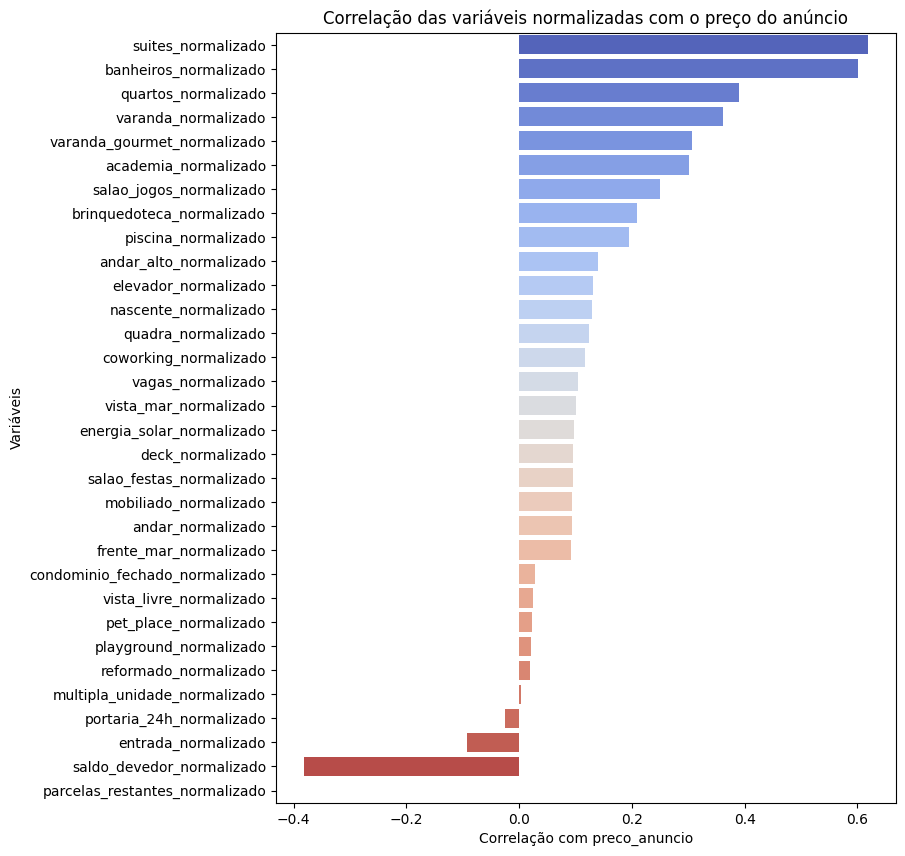

In [139]:
colunas_normalizadas = [col for col in df.columns if "normalizado" in col]

df_corr = df[["preco_anuncio"] + colunas_normalizadas].copy()

df_corr["preco_anuncio"] = pd.to_numeric(
    df_corr["preco_anuncio"],
    errors="coerce"
)

correlacao_preco = (
    df_corr
    .corr(numeric_only=True)["preco_anuncio"]
    .drop("preco_anuncio")
    .sort_values(ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

sns.barplot(
    x=correlacao_preco.values,
    y=correlacao_preco.index,
    hue=correlacao_preco.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlação das variáveis normalizadas com o preço do anúncio")
plt.xlabel("Correlação com preco_anuncio")
plt.ylabel("Variáveis")

plt.show()

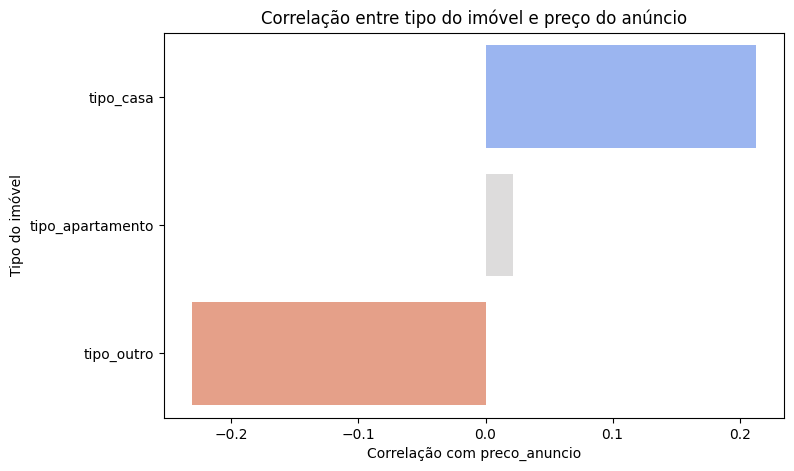

In [140]:
df_tipo = pd.get_dummies(
    df["tipo_imovel_normalizado"],
    prefix="tipo"
)

df_corr_tipo = pd.concat(
    [df["preco_anuncio"], df_tipo],
    axis=1
)

correlacao_tipo_preco = (
    df_corr_tipo
    .corr(numeric_only=True)["preco_anuncio"]
    .drop("preco_anuncio")
    .sort_values(ascending=False)
)

df["preco_anuncio"] = pd.to_numeric(df["preco_anuncio"], errors="coerce")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    x=correlacao_tipo_preco.values,
    y=correlacao_tipo_preco.index,
    hue=correlacao_tipo_preco.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlação entre tipo do imóvel e preço do anúncio")
plt.xlabel("Correlação com preco_anuncio")
plt.ylabel("Tipo do imóvel")

plt.show()

In [141]:
df.tipo_imovel_normalizado.value_counts()

tipo_imovel_normalizado
apartamento    739
outro          151
casa           142
Name: count, dtype: int64

# Tratamento de dados(criando pipeline)

In [127]:
# Mantem o df_final consolidado na etapa 12; nao recria a partir de df bruto.
df_final = df.copy()


In [128]:
# Removendo cidades que nao sao Fortaleza, se a coluna ainda existir no df_final.
cidades_remover = ["Eusébio", "Aquiraz", "Caucaia", "Maracanaú"]

if "cidade" in df_final.columns:
    df_final = df_final[~df_final["cidade"].isin(cidades_remover)].copy()
else:
    print("Coluna cidade removida do df_final; filtro de cidade nao aplicado nesta etapa.")


In [142]:
corr_preco = df_final.corr(numeric_only=True)["preco_anuncio"]

colunas_numericas_manter = corr_preco[
    (corr_preco >= 0.10) | (corr_preco.index == "preco_anuncio")
].index.tolist()

colunas_categoricas_manter = [
    "bairro_normalizado",
    "tipo_imovel_normalizado"
]

df_final = df_final[
    colunas_numericas_manter + colunas_categoricas_manter
].copy()

In [143]:
colunas_remover = [
    "bairro", "cidade", "descrição", "listing_id", "titulo", "estado",
    "rua", "numero", "endereco", "tem_varanda_gourmet", "descricao",
    "corretora", "url", "imagem_url", "_titulo_n", "_descricao_n",
    "_endereco_n", "_texto_full", "cidade_normalizada", "andar", "vaga",
    "vagas", "saldo_devedor_normalizado", "parcelas_restantes_normalizado",
    "entrada_normalizado", "observacoes_extraidas_normalizado",
    "multipla_unidade_normalizado", "energia_solar_normalizado", "nota_media", "rua_normalizada", "vista_mar_normalizado",
    "varanda_gourmet_normalizado", "nascente_normalizado", "andar_alto_normalizado",
    "reformado_normalizado", "mobiliado_normalizado", "frente_mar_normalizado",
    "vista_livre_normalizado", "tipo_anuncio_normalizado", "apartamento_ou_casa", "tipo_imovel",
    
]

colunas_originais_com_normalizadas = [
    "bairro",
    "rua",
    "metragem",
    "quartos",
    "banheiros",
    "suites",
    "estacionamentos",
    "tem_portaria_24h",
    "tem_vista_pro_mar",
    "tem_condominio_fechado",
    "tem_piscina",
    "tem_deck",
    "tem_varanda",
    "tem_academia",
    "tem_salao_festas",
    "tem_salao_jogos",
    "tem_quadra_campo",
]

df_final = df_final.drop(columns=colunas_remover, errors="ignore")
df_final = df_final.drop(columns=colunas_originais_com_normalizadas, errors="ignore")

In [144]:
df_final.columns


Index(['preco_anuncio', 'latitude', 'longitude', 'metragem_normalizada',
       'quartos_normalizado', 'banheiros_normalizado', 'suites_normalizado',
       'andar_normalizado', 'piscina_normalizado', 'varanda_normalizado',
       'academia_normalizado', 'salao_jogos_normalizado',
       'brinquedoteca_normalizado', 'coworking_normalizado',
       'elevador_normalizado', 'bairro_normalizado',
       'tipo_imovel_normalizado'],
      dtype='object')

In [145]:
df_final["tipo_imovel_normalizado"].value_counts()

tipo_imovel_normalizado
apartamento    739
casa           142
Name: count, dtype: int64

In [132]:
df_final = df_final[df_final["tipo_imovel_normalizado"] != "outro"]

In [146]:
df_final.shape[0]

881

## Matriz de correlação

In [135]:
df_final.columns

Index(['preco_anuncio', 'latitude', 'longitude', 'anuncio_criado',
       'bairro_normalizado', 'metragem_normalizada', 'quartos_normalizado',
       'banheiros_normalizado', 'suites_normalizado', 'andar_normalizado',
       'vagas_normalizado', 'portaria_24h_normalizado',
       'condominio_fechado_normalizado', 'piscina_normalizado',
       'deck_normalizado', 'varanda_normalizado', 'academia_normalizado',
       'salao_festas_normalizado', 'salao_jogos_normalizado',
       'quadra_normalizado', 'playground_normalizado',
       'brinquedoteca_normalizado', 'coworking_normalizado',
       'pet_place_normalizado', 'elevador_normalizado',
       'tipo_imovel_normalizado'],
      dtype='object')

C:\Users\andriel_orbi\AppData\Local\Temp\ipykernel_25712\1121001416.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


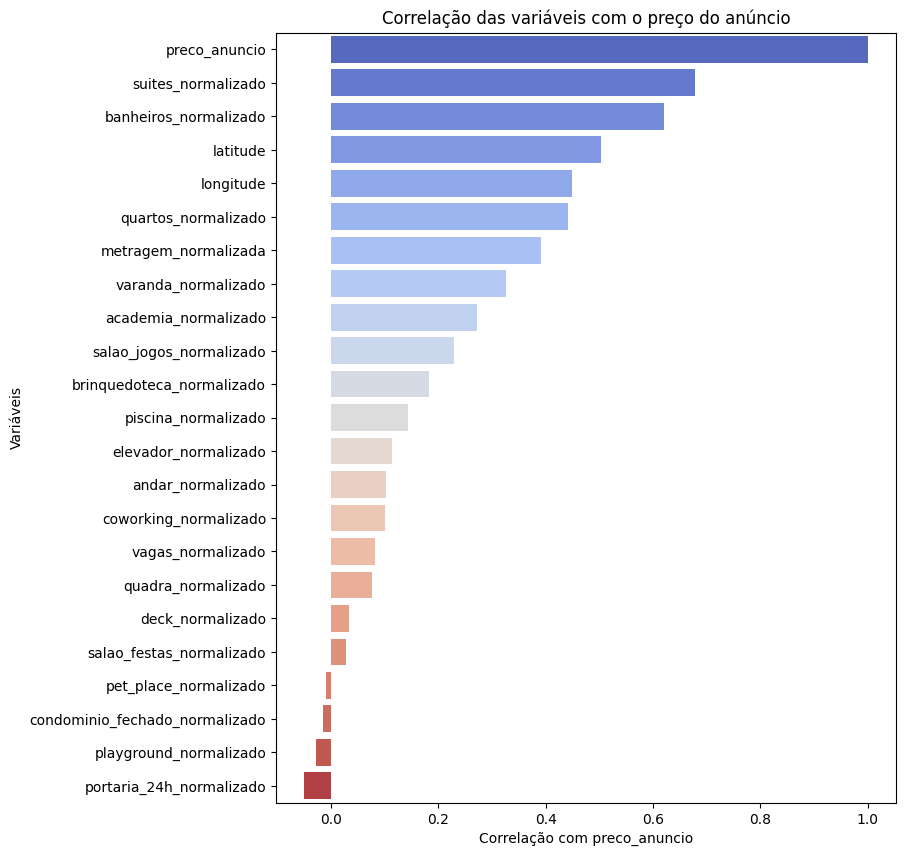

In [137]:
df_final["preco_anuncio"] = pd.to_numeric(
    df_final["preco_anuncio"],
    errors="coerce"
)

correlacao_preco = (
    df_final
    .corr(numeric_only=True)["preco_anuncio"]
    .sort_values(ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

sns.barplot(
    x=correlacao_preco.values,
    y=correlacao_preco.index,
    palette="coolwarm"
)

plt.title("Correlação das variáveis com o preço do anúncio")
plt.xlabel("Correlação com preco_anuncio")
plt.ylabel("Variáveis")

plt.show()